# =========================================
# EJERCICIO 2 - ANALISIS DE CORRELACION
# =========================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar dataset
corr_df = pd.read_csv("https://raw.githubusercontent.com/MendezBy02/Parcial4-Abel-Antonio-Escobar-Mendez-25-1449-2022/refs/heads/main/archivos/clave_B_correlacion.csv")

# Mostrar primeras filas
corr_df.head()

,cliente_id,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
0,B-C0001,37,818,9,43.76,8.24,0,5,8.56,456.85
1,B-C0002,29,693,5,30.73,9.25,0,3,16.91,215.38
2,B-C0003,26,552,7,42.77,7.24,3,6,29.86,293.80
3,B-C0004,31,980,9,67.02,7.61,1,6,17.09,603.80
4,B-C0005,37,965,7,51.24,9.40,0,7,12.21,521.52


Explicación:

Se carga el dataset correspondiente al análisis de correlación para identificar relaciones entre variables numéricas relacionadas con el comportamiento de los clientes.

In [3]:
# Informacion general
corr_df.info()

# Valores nulos
corr_df.isnull().sum()

# Estadisticas generales
corr_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226 entries, 0 to 225
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cliente_id          226 non-null    object 
 1   edad                226 non-null    int64  
 2   ingresos_mensuales  226 non-null    int64  
 3   frecuencia_compra   226 non-null    int64  
 4   ticket_promedio     225 non-null    float64
 5   satisfaccion        225 non-null    float64
 6   reclamos            226 non-null    int64  
 7   uso_app             226 non-null    int64  
 8   tiempo_respuesta    225 non-null    float64
 9   consumo_total       226 non-null    float64
dtypes: float64(4), int64(5), object(1)
memory usage: 17.8+ KB


,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
count,226.000000,226.000000,226.000000,225.000000,225.000000,226.000000,226.000000,225.000000,226.000000
mean,35.716814,882.752212,7.172566,59.164622,7.556667,1.384956,5.185841,21.525511,439.469292
std,9.537732,263.237047,3.088523,15.233680,1.185569,1.435284,2.002437,6.233452,184.435972
min,18.000000,300.000000,1.000000,8.000000,3.070000,0.000000,0.000000,5.000000,67.440000
25%,29.000000,703.000000,6.000000,48.960000,6.960000,0.000000,4.000000,17.600000,335.435000
50%,36.000000,863.500000,7.000000,58.460000,7.650000,1.000000,5.000000,21.170000,430.665000
75%,42.000000,1078.750000,8.000000,69.580000,8.260000,2.000000,7.000000,24.780000,530.425000
max,65.000000,1503.000000,28.000000,111.380000,10.000000,9.000000,10.000000,43.800000,1558.440000


Explicación:

Se revisa la estructura del dataset, los tipos de datos y posibles valores nulos para asegurar la calidad de la información antes del análisis.

In [4]:
# Variables numericas
variables_numericas = corr_df.select_dtypes(include=np.number)

# Mostrar columnas
variables_numericas.columns

Index(['edad', 'ingresos_mensuales', 'frecuencia_compra', 'ticket_promedio',
       'satisfaccion', 'reclamos', 'uso_app', 'tiempo_respuesta',
       'consumo_total'],
      dtype='object')

Explicación:

Se seleccionan únicamente las variables numéricas debido a que la correlación solo puede calcularse entre datos cuantitativos.

In [5]:
# Matriz de correlacion
matriz_corr = variables_numericas.corr()

# Mostrar matriz
matriz_corr

,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
edad,1.000000,-0.056041,0.005589,0.134499,0.078845,-0.066025,-0.030510,-0.081160,0.073411
ingresos_mensuales,-0.056041,1.000000,0.153714,0.605081,-0.003427,0.008559,0.059033,-0.028607,0.400372
frecuencia_compra,0.005589,0.153714,1.000000,0.114041,0.262397,-0.129349,0.522269,-0.232357,0.869690
ticket_promedio,0.134499,0.605081,0.114041,1.000000,-0.003212,0.005073,0.026057,-0.045059,0.507290
satisfaccion,0.078845,-0.003427,0.262397,-0.003212,1.000000,-0.771212,0.246496,-0.630479,0.291447
reclamos,-0.066025,0.008559,-0.129349,0.005073,-0.771212,1.000000,0.024482,0.563876,-0.158328
uso_app,-0.030510,0.059033,0.522269,0.026057,0.246496,0.024482,1.000000,-0.173179,0.523872
tiempo_respuesta,-0.081160,-0.028607,-0.232357,-0.045059,-0.630479,0.563876,-0.173179,1.000000,-0.296384
consumo_total,0.073411,0.400372,0.869690,0.507290,0.291447,-0.158328,0.523872,-0.296384,1.000000


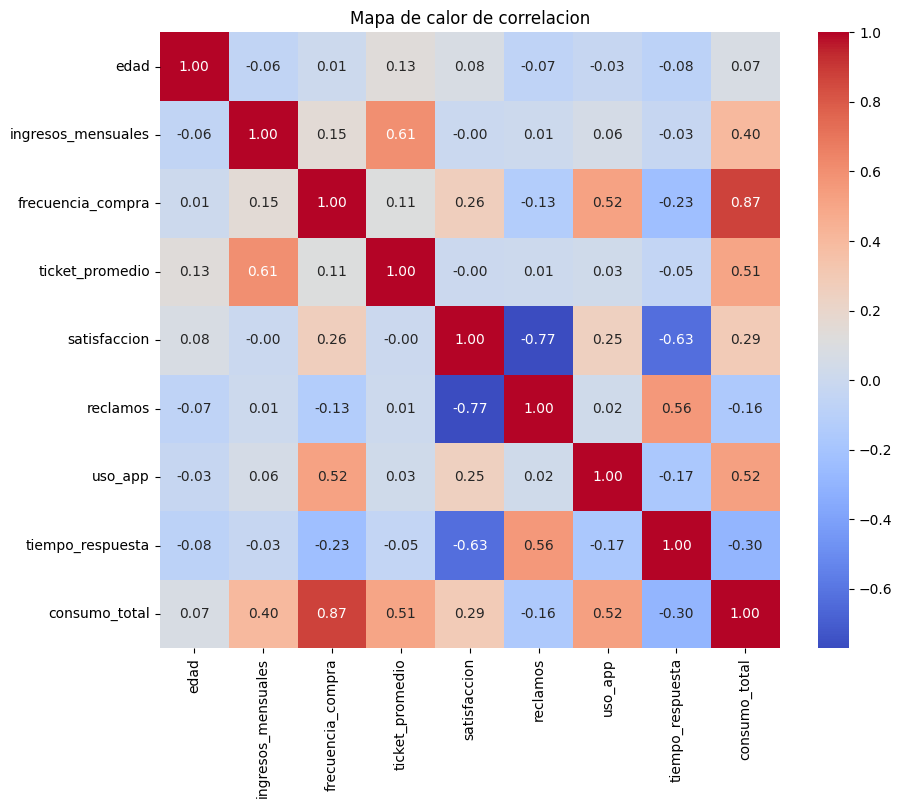

In [6]:
# Tamaño del grafico
plt.figure(figsize=(10,8))

# Mapa de calor
sns.heatmap(
    matriz_corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

# Titulo
plt.title("Mapa de calor de correlacion")

# Mostrar
plt.show()

Explicación:

El mapa de calor permite visualizar la intensidad de las relaciones positivas y negativas entre las variables numéricas del dataset.

#Correlaciones positivas más importantes
1. La relación entre frecuencia_compra y consumo_total es alta y positiva (0.87).

2. Existe una correlación positiva entre ingresos_mensuales y ticket_promedio (0.61).

3. Se observa una correlación positiva entre uso_app y consumo_total (0.52).

4. La variable ticket_promedio también presenta correlación positiva con consumo_total (0.51).



#Correlaciones negativas importantes
1. Existe una fuerte correlación negativa entre satisfaccion y reclamos (-0.77).

2. Se observa una correlación negativa entre satisfaccion y tiempo_respuesta (-0.63).

3. La variable frecuencia_compra presenta correlación negativa con tiempo_respuesta (-0.23).

4. También existe una correlación negativa entre consumo_total y tiempo_respuesta (-0.30).

#Interpretaciones de negocio

1. La frecuencia de compra tiene una fuerte relación positiva con el consumo total, lo que indica que los clientes frecuentes generan mayores ingresos para la empresa.


2. Los clientes con mayores ingresos mensuales presentan tickets promedio más altos, lo que permite identificar segmentos premium.



3. El uso de la aplicación móvil se relaciona positivamente con el consumo total, indicando que la app puede incentivar las compras y mejorar la experiencia del cliente.

#Conclusion
El análisis de correlación permitió identificar relaciones importantes entre variables relacionadas con el comportamiento de los clientes. Se encontró que la frecuencia de compra, el uso de la aplicación y los ingresos mensuales influyen directamente en el consumo total y el ticket promedio. Además, se observó que los reclamos y el tiempo de respuesta afectan negativamente la satisfacción del cliente. Esta información puede ayudar a la empresa a mejorar estrategias comerciales y de atención al cliente.